In [4]:
%load_ext autoreload
%autoreload 2

In [29]:
from optimization_research.ml_constraints import MulticlassSolver
from ortools.linear_solver import pywraplp

2

### TESTINGS

In [6]:
import numpy as np
import pandas as pd

In [23]:


y_hat = np.array([[0.5, 0.5],
                  [0.5, 0.5],
                  [0. , 1. ],
                  [0. , 1. ]])
groups = np.array(["group1", "group1", "group2", "group3"])
global_constraint = [0, 1]
local_constraint = {"group1": [0, 1], "group2": [0, 1]}
cost_matrix = np.array([[0, 1], 
                        [1, 0]])

my_solver = MulticlassSolver(y_hat, groups, cost_matrix, global_constraint, local_constraint)

my_solver.solve() #should assert


ASD
<ortools.linear_solver.pywraplp.Constraint; proxy of <Swig Object of type 'operations_research::MPConstraint *' at 0x0000020752468660> >
Status:  2
Objective function:  0.0


array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [4]:
#Infeasible case because of groups
my_solver = MulticlassSolver()

y_hat = np.array([[0.5, 0.5],
                  [0.5, 0.5],
                  [0. , 1. ],
                  [0. , 1. ]])
groups = np.array(["group1", "group1", "group2", "group3"])
global_constraint = None
local_constraint = {"group1": [0, 0]}
my_solver.solve(y_hat, groups, cost_matrix, global_constraint, local_constraint) #should assert

Status:  2
Objective function:  0.0


array([[0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [133]:
#Infeasible case because of global constraint
y_hat = np.array([[0.5, 0.5],
                  [0.5, 0.5],
                  [0. , 1. ],
                  [0. , 1. ]])
groups = np.array(["group1", "group1", "group2", "group3"])
global_constraint = [2, 1]
local_constraint = None
status, _, _ = solve_multiclass(y_hat, groups, cost_matrix, global_constraint, local_constraint) #should assert
status == pywraplp.Solver.INFEASIBLE

True

In [134]:
#No constraints at all
y_hat = np.array([[0.5, 0.5],
                  [0.5, 0.5],
                  [0. , 1. ],
                  [0. , 1. ]])
groups = np.array(["group1", "group1", "group2", "group3"])
cost_matrix = np.array([[1,      2], 
                        [999999, 4]])
global_constraint = None
local_constraint = None
status, _, results = solve_multiclass(y_hat, groups, cost_matrix, global_constraint, local_constraint) #should assert
status == pywraplp.Solver.OPTIMAL

True

In [137]:
#No constraints at all
y_hat = np.array([[0.5, 0.5],
                  [0.5, 0.5],
                  [0. , 1. ],
                  [0. , 1. ]])
groups = np.array(["group1", "group1", "group2", "group3"])
cost_matrix = np.array([[1    , 2], 
                        [99999, 99999999]])
global_constraint = [None, 3]
local_constraint = None
status, objective_value, results = solve_multiclass(y_hat, groups, cost_matrix, global_constraint, local_constraint) #should assert
status == pywraplp.Solver.OPTIMAL

print("results\n", results)
print("objective_value", objective_value)

results
 [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]
objective_value 299998.0


In [125]:
cm = repeat_cost_matrix(cost_matrix, y_hat.shape[0])

In [129]:
#show np array with no scientific notation
np.set_printoptions(suppress=True)

((cm.transpose(0, 2, 1) * y_hat[:, :, np.newaxis]).transpose(0, 2, 1))

array([[[    0.5,     1. ],
        [49999.5,     2. ]],

       [[    0.5,     1. ],
        [49999.5,     2. ]],

       [[    0. ,     2. ],
        [    0. ,     4. ]],

       [[    0. ,     2. ],
        [    0. ,     4. ]]])

In [48]:
#No constraints at all
y_hat = np.array([[0.5, 0.5],
                  [0.5, 0.5],
                  [0.1, 0.9],
                  [0.1, 0.9]])
groups = np.array(["group1", "group1", "group2", "group3"])
cost_matrix = np.array([[1, 2], 
                        [99999, 4]])
global_constraint = None
local_constraint = None
status, _, results = solve_multiclass(y_hat, groups, cost_matrix, global_constraint, local_constraint) #should assert
status == pywraplp.Solver.OPTIMAL

np.allclose(results, np.array([[0., 1.],
                               [0., 1.],
                               [0., 1.],
                               [0., 1.]]))

False

array([3., 3., 0., 0.])

In [83]:
results

array([[0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.]])

In [76]:
cm

array([[[    1,     2],
        [99999,     4]],

       [[    1,     2],
        [99999,     4]],

       [[    1,     2],
        [99999,     4]],

       [[    1,     2],
        [99999,     4]]])

NameError: name 'pywraplp' is not defined

In [50]:
#No constraints at all
y_hat = np.array([[0.0, 1.0],
                  [1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0]])
groups = np.array(["group1", "group1", "group2", "group3"])
cost_matrix = np.array([[1    , 2], 
                        [99999, 4]])

global_constraint = [None, 3]
local_constraint = None
status, _, results = solve_multiclass(y_hat, groups, cost_matrix, global_constraint, local_constraint) #should assert
status == pywraplp.Solver.OPTIMAL

results

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

In [73]:
np.allclose(y_hat.sum(axis=1), 1)

True

In [ ]:
solver.a

In [72]:
#validate input, if the sum of the predictions is equal to 1
assert y_hat.sum(axis=1) == 1

array([ True,  True,  True,  True])

In [52]:
x

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [53]:
y_h = np.array([0.5, 0.5, 1.0, 1.0])
y_h = prepare_y_hat(y_h)

cm = repeat_cost_matrix(cost_matrix, 4)

In [56]:
x

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

4.0

In [ ]:
def apply_function_on_all_elements_in_2darray(array, function):
    for i in range(array.shape[0]):
        for j in range(array.shape[1]):
            array[i, j] = function(array[i, j])
    return array

In [65]:
x

array([[R00, R01],
       [R10, R11],
       [R20, R21],
       [R30, R31]], dtype=object)

In [70]:
import pandas as pd


array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [64]:
#apply on all variables a method to get solution_value
zz = np.array([[x[i][j].solution_value() for j in range(2)] for i in range(4)])
zz

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [30]:
solver = pywraplp.Solver.CreateSolver('GLOP')

In [35]:
num_vars = np.array([solver.NumVar(0, 1, 'R{}'.format(i)) for i in range(4)])
weights = np.array([0.8, 0.2, 0.5, 0.6])
objective_function = (num_vars * weights).sum()

In [36]:
solver.Minimize(objective_function)

In [37]:
status = solver.Solve()

In [38]:

status

0

In [43]:
[x.solution_value() for x in num_vars]

[0.0, 0.0, 0.0, 0.0]

(-0.01, 1.01)

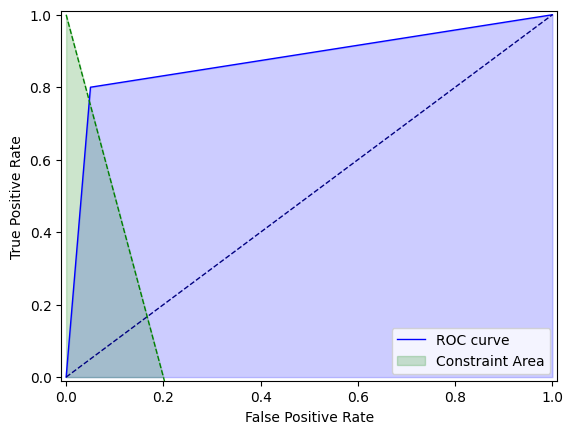

In [113]:
#plot a roc curve for a binary classification problem
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#on random classification task with 2 classes
from sklearn.datasets import make_classification

X, y =  make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
clf = LogisticRegression()
clf.fit(X_train, y_train)


y_score = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_score)
fpr, tpr =[0, 0.05, 1], [0, 0.8, 1]


roc_auc = auc(fpr, tpr)

#plot the roc curve
plt.figure()
lw = 1
plt.plot(fpr, tpr, color='blue', lw=lw, label='ROC curve')

#fill between
plt.fill_between(fpr, tpr, alpha=0.2, color='blue')

#plot random line
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
#add labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')



#Add a line with slope 0.3 and intercept 0.2
slope = -5
intercept = 1

plt.plot([0, 1], [intercept, intercept+slope], color='green', lw=lw, linestyle='--')
#fill between this line
plt.fill_between([0,0.2], [intercept, 0], alpha=0.2, color='green', label= "Constraint Area")





#add legend
plt.legend(loc="lower right")


#add boundaries
eps = 0.01
plt.xlim([0.0-eps, 1.0+eps])
plt.ylim([0.0-eps, 1.0+eps])